# Composer Demo: Convergence Comparison with Canonical Initialization

This notebook compares convergence across three MalthusJAX pipelines using a shared initial population and 30 seeds. The configuration is defined in `bench_engine_convergence.toml` and loaded with `Composer.from_toml()`.


In [8]:
from pathlib import Path
from malthusjax.composer import Composer

notebook_dir = Path.cwd()
toml_path = notebook_dir / "bench_engine_convergence.toml"
print(f"Loading TOML from: {toml_path}")
print("Using canonical shared initialization and Composer.from_toml()")

Loading TOML from: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX/examples/_DEMO_COMPOSER/bench_engine_convergence.toml
Using canonical shared initialization and Composer.from_toml()


In [9]:
# Shared experiment settings
fitness = "ellipsoidal:dim=10"
pop_size = 100
generations = 100
bounds = [-5.0, 5.0]
genome_length = 100

seeds = tuple(range(42, 72))  # 30 seeds

print(f"Configured {len(seeds)} seeds")

Configured 30 seeds


## Comparison Pipelines

This experiment compares three MalthusJAX pipelines with canonical shared initialization across 30 seeds.
- `malthusjax_default`: standard MalthusJAX with elite-pool selection.
- `malthusjax_roulette_evosaxops`: roulette selection with Evosax wrapper operators.
- `malthusjax_tournament_evosaxops`: tournament selection with Evosax wrapper operators.

In [10]:
comparison = Composer.from_toml(
    str(toml_path),
    shared_initial_population=True,
    pop_seed=123,
)

print(f"Pipelines loaded: {comparison.names}")
print(f"Seeds used: {len(seeds)}")

pipelines: 100%|██████████| 4/4 [00:45<00:00, 11.45s/it]

Pipelines loaded: ['malthusjax_default', 'malthusjax_roulette_evosaxops', 'malthusjax_tournament_evosaxops', 'evosax_simplega']
Seeds used: 30


In [11]:
summary = comparison.summary_table()

print("Aggregated summary:")
for pipeline_name, metrics in summary.items():
    best_fitness = metrics.get("best_fitness")
    print(f"- {pipeline_name}: best_fitness mean={best_fitness:.6f}")

seed_index = 0
seed_history = comparison.convergence_data(seed_index=seed_index)
print(f"\nConvergence history available for seed {seed_index}:")
for pipeline_name, history in seed_history.items():
    print(f"- {pipeline_name}: {len(history)} generations")

Aggregated summary:
- malthusjax_default: best_fitness mean=-193.855494
- malthusjax_roulette_evosaxops: best_fitness mean=-193.660260
- malthusjax_tournament_evosaxops: best_fitness mean=-193.779128
- evosax_simplega: best_fitness mean=-189.512240

Convergence history available for seed 0:
- malthusjax_default: 100 generations
- malthusjax_roulette_evosaxops: 100 generations
- malthusjax_tournament_evosaxops: 100 generations
- evosax_simplega: 100 generations


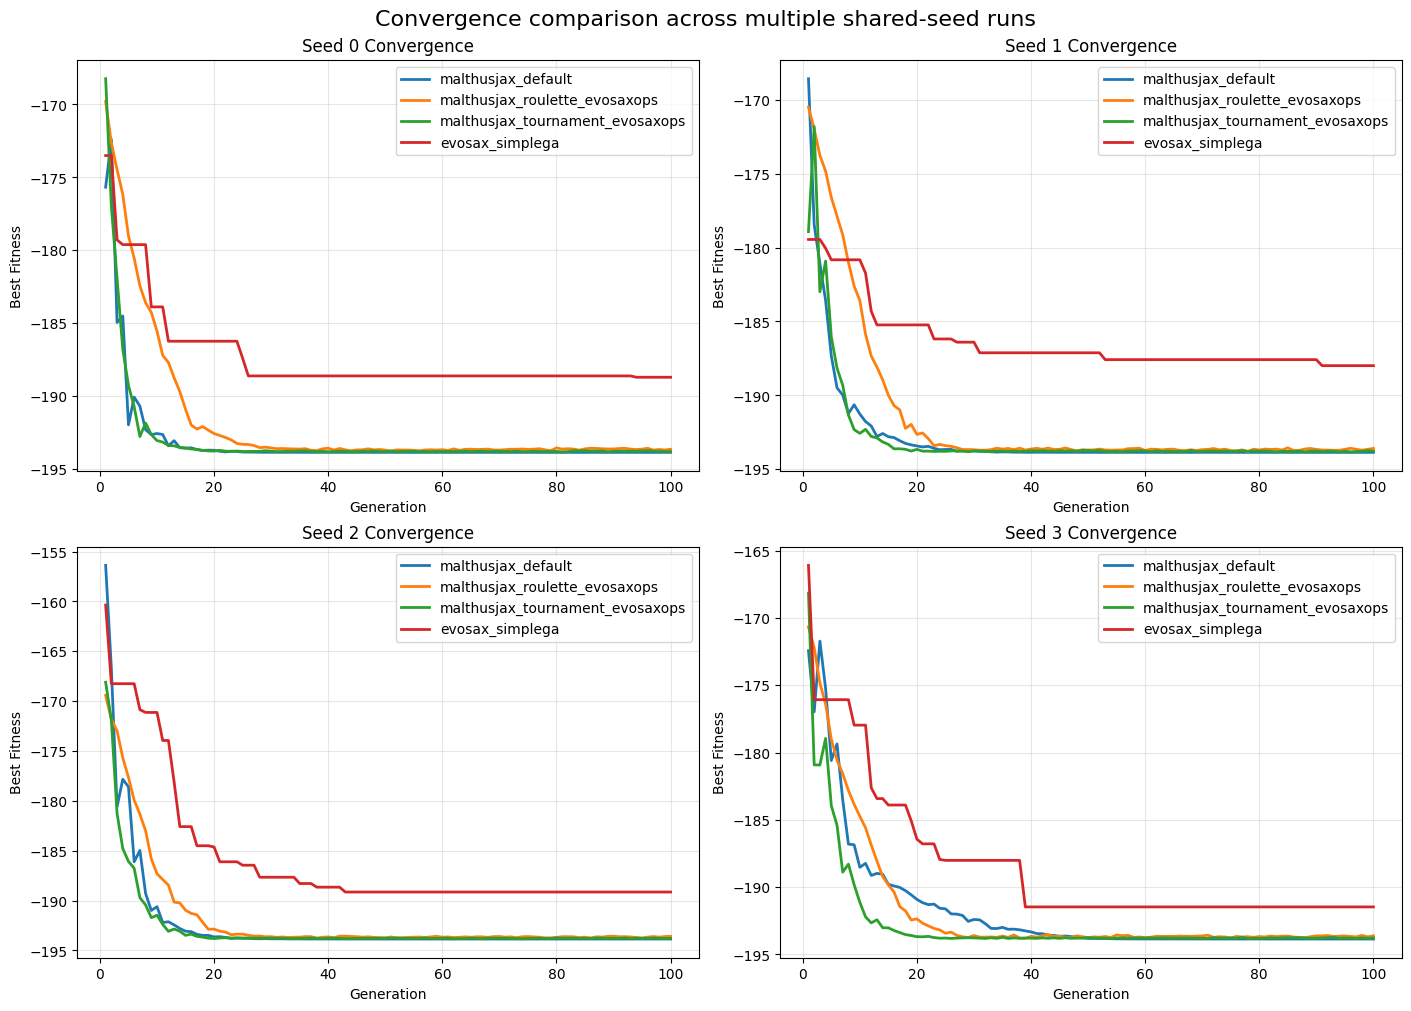

In [12]:
import matplotlib.pyplot as plt

seed_count = min(4, len(seeds))
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()

for seed_index in range(seed_count):
    ax = axes[seed_index]
    comparison.plot_convergence(
        seed_index=seed_index,
        ax=ax,
        title=f"Seed {seed_index} Convergence",
    )
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best Fitness")

for extra_ax in axes[seed_count:]:
    extra_ax.axis("off")

plt.suptitle("Convergence comparison across multiple shared-seed runs", fontsize=16)
plt.show()

In [13]:
comparison.summary_table()

{'malthusjax_default': {'initial_fitness': 167.81597900390625,
  'best_fitness': -193.8554941813151,
  'final_generation': 100.0,
  'total_evaluations': 10000.0},
 'malthusjax_roulette_evosaxops': {'initial_fitness': 167.81597900390625,
  'best_fitness': -193.66026000976564,
  'final_generation': 100.0,
  'total_evaluations': 10000.0},
 'malthusjax_tournament_evosaxops': {'initial_fitness': 167.81597900390625,
  'best_fitness': -193.7791280110677,
  'final_generation': 100.0,
  'total_evaluations': 10000.0},
 'evosax_simplega': {'best_fitness': -189.51224009195963,
  'total_generations': 100.0,
  'final_generation': 100.0,
  'total_evaluations': 10000.0,
  'pop_size': 100.0}}

In [14]:
comparison.convergence_data()

{'malthusjax_default': [{'generation': 1,
   'best_fitness': -175.6736297607422,
   'mean_fitness': -79.33216857910156},
  {'generation': 2,
   'best_fitness': -172.38584899902344,
   'mean_fitness': -114.28995513916016},
  {'generation': 3,
   'best_fitness': -184.95281982421875,
   'mean_fitness': -136.68035888671875},
  {'generation': 4,
   'best_fitness': -184.50257873535156,
   'mean_fitness': -153.42648315429688},
  {'generation': 5,
   'best_fitness': -191.96575927734375,
   'mean_fitness': -168.0585479736328},
  {'generation': 6,
   'best_fitness': -190.0648956298828,
   'mean_fitness': -179.27915954589844},
  {'generation': 7,
   'best_fitness': -190.6892547607422,
   'mean_fitness': -184.0914764404297},
  {'generation': 8,
   'best_fitness': -192.30564880371094,
   'mean_fitness': -187.11105346679688},
  {'generation': 9,
   'best_fitness': -192.63377380371094,
   'mean_fitness': -188.88710021972656},
  {'generation': 10,
   'best_fitness': -192.56483459472656,
   'mean_fitne